# Лабораторная 7

## 1. Построение описательный статистик двух финансовых активов

### Импорт библиотек:

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, coint
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model

### Загрузка исторических цен (закрытия на конец дня) и расчёт ежедневных доходностей

In [22]:
tickers = ['MSFT', 'AAPL']
start_date = '2020-01-01'
end_date = '2024-12-31'

data = yf.download(tickers, start=start_date, end=end_date)['Close']  # type: ignore
data.dropna(inplace=True)
returns = data.pct_change().dropna()

[*********************100%***********************]  2 of 2 completed


### Построение графика цен

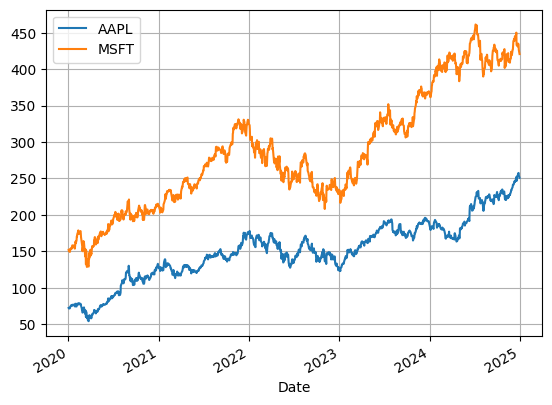

In [23]:
data.plot()
plt.grid()
plt.legend()
plt.show()

### Описательные статистики дневных доходностей

In [24]:
returns.describe()

Ticker,AAPL,MSFT
count,1256.000000,1256.000000
mean,0.001189,0.000995
std,0.019962,0.019217
min,-0.128647,-0.147390
25%,-0.008426,-0.008248
50%,0.001210,0.001113
75%,0.012017,0.010947
max,0.119808,0.142169


### Графики Бокса-Вискера дневных доходностей

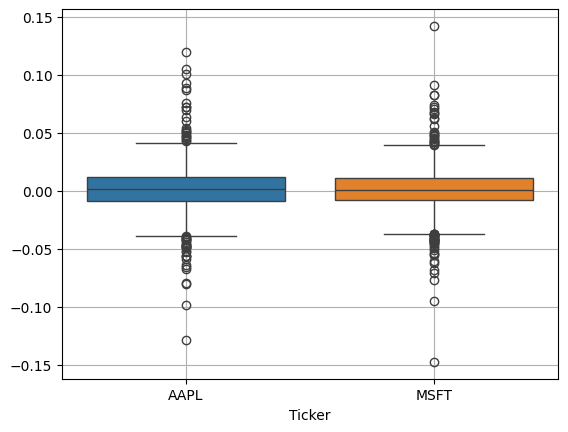

In [25]:
sns.boxplot(returns)
plt.grid()
plt.show()

### Гистограммы распределения дневных доходностей

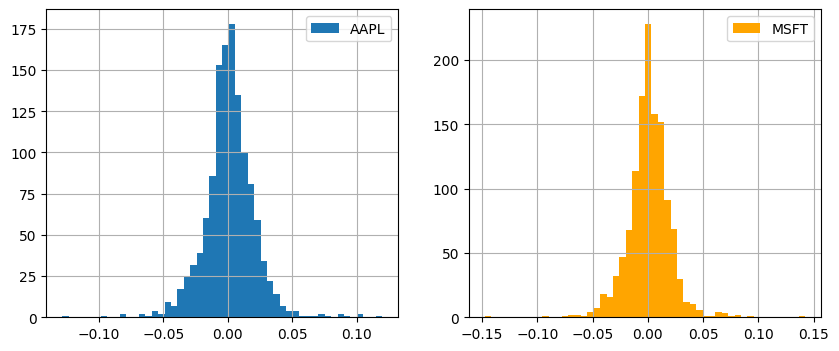

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

ax1.hist(returns['AAPL'], bins=50, label='AAPL')
ax1.grid()
ax1.legend()

ax2.hist(returns['MSFT'], bins=50, color='orange', label='MSFT')
ax2.grid()
ax2.legend()

plt.show()

### График доходностей

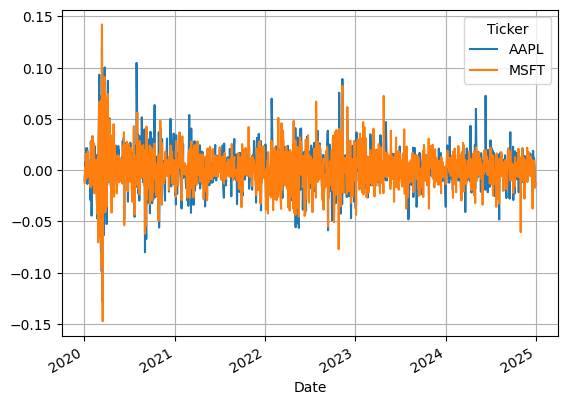

In [27]:
returns.plot()
plt.grid()
plt.show()

### Критерии стационарности ряда: ADF-test и KPSS-test

In [28]:
def adf_test(series, title=''):
    print(f'Augmented Dickey-Fuller Test ({title}):')
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values: {result[4]}')
    print('Reject H0 (Stationary)' if result[1] <= 0.05 else 'Fail to Reject H0 (Non-Stationary)')
    print('---')

def kpss_test(series, title=''):
    print(f'KPSS Test ({title}):')
    result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'KPSS Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values: {result[3]}')
    print('Fail to Reject H0 (Stationary)' if result[1] <= 0.05 else 'Reject H0 (Non-Stationary)')
    print('---')

# Применяем тесты к доходностям
for ticker in tickers:
    adf_test(returns[ticker], title=ticker)
    kpss_test(returns[ticker], title=ticker)

Augmented Dickey-Fuller Test (MSFT):
ADF Statistic: -11.299803
p-value: 0.000000
Critical Values: {'1%': np.float64(-3.4356048614183443), '5%': np.float64(-2.8638605461891617), '10%': np.float64(-2.5680054872544145)}
Reject H0 (Stationary)
---
KPSS Test (MSFT):
KPSS Statistic: 0.095016
p-value: 0.100000
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Reject H0 (Non-Stationary)
---
Augmented Dickey-Fuller Test (AAPL):
ADF Statistic: -11.351127
p-value: 0.000000
Critical Values: {'1%': np.float64(-3.4356048614183443), '5%': np.float64(-2.8638605461891617), '10%': np.float64(-2.5680054872544145)}
Reject H0 (Stationary)
---
KPSS Test (AAPL):
KPSS Statistic: 0.108102
p-value: 0.100000
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Reject H0 (Non-Stationary)
---


/tmp/ipykernel_45019/3555273386.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')
/tmp/ipykernel_45019/3555273386.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')


### p-value обоих тестов близко к нулю, ряды стационарны. Значит, можно на их основе построить GARCH-модель

## 2. Построение модели GARCH(1,1) на основе нормальных случайных величин

Модель GARCH(1,1) (Generalized Autoregressive Conditional Heteroskedasticity) для временного ряда доходностей $r_t$ записывается как: $$\begin{gathered} r_t = \mu + \varepsilon_t, \\ \varepsilon_t=\sigma_t z_t, \\ \sigma^2_t=\omega + \alpha \varepsilon^2_{t-1} + \beta \sigma^2_{t-1} \end{gathered} $$  где $r_t$ - исследуемый ряд, $z_t$ - случайные величины, $\omega > 0$, $\alpha, \beta \ge 0$, $\alpha + \beta < 1$ (условие стационарности). $\mu$ задаётся в зависимости от центрированности ряда.
На реальных данных параметры чаще всего оцениваются методом максимального правдоподобия.

In [ ]:
random_variables = np.random.normal(1000)


## 5. GARCH(1,1) на реальных данных

In [ ]:


returns_scaled = returns * 100
model = arch_model(returns_scaled['AAPL'])

In [30]:
model_fitted = model.fit(disp='off')

In [31]:
print(model_fitted.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   AAPL   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2507.20
Distribution:                  Normal   AIC:                           5022.39
Method:            Maximum Likelihood   BIC:                           5042.93
                                        No. Observations:                 1256
Date:                Mon, Mar 30 2026   Df Residuals:                     1255
Time:                        22:49:37   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1592  5.124e-02      3.107  1.890e-03 [5.877e-0

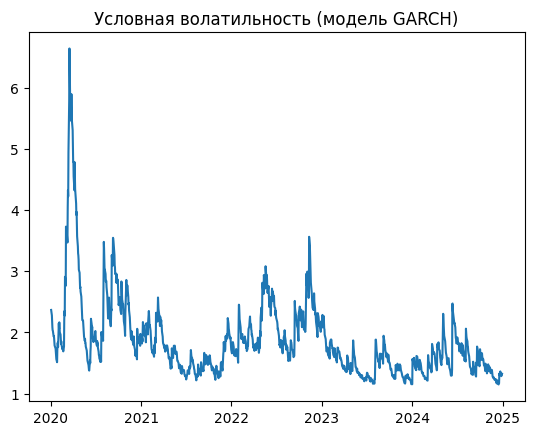

In [32]:
conditional_volatility = model_fitted.conditional_volatility
plt.plot(conditional_volatility)
plt.title('Условная волатильность (модель GARCH)')
plt.show()

In [ ]:
forecasts = model_fitted.forecast(horizon=5)
print("\nПрогноз дисперсии на 5 шагов:")
print(forecasts.variance.iloc[-1])


Прогноз дисперсии на 5 шагов:
h.001    1.848062
h.002    1.899603
h.003    1.949715
h.004    1.998438
h.005    2.045809
           ...   
h.361    3.706516
h.362    3.706518
h.363    3.706520
h.364    3.706522
h.365    3.706524
Name: 2024-12-30 00:00:00, Length: 365, dtype: float64


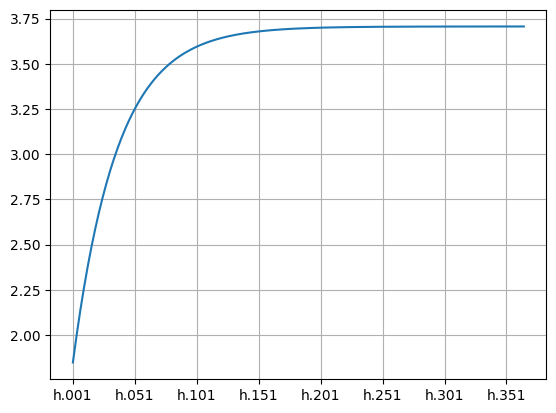

In [45]:
forecasts.variance.iloc[-1].plot()
plt.grid()
plt.show()

In [43]:
test_data = yf.download('AAPL', start='2025-01-01', end='2025-12-31')['Close']  # type: ignore
returns_test = test_data.pct_change().dropna()
test_data.head()

[*********************100%***********************]  1 of 1 completed


Ticker,AAPL
Date,
2025-01-02,242.525162
2025-01-03,242.037811
2025-01-06,243.668900
2025-01-07,240.894073
2025-01-08,241.381409


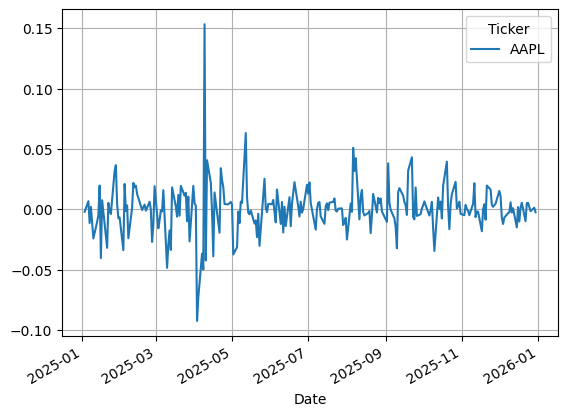

In [44]:
returns_test.plot()
#forecasts.variance.iloc[-1].plot()
plt.grid()
plt.show()